# 02 — Exploratory Data Analysis (EDA)
## Paddy Yield Predictor

EDA checks data quality, distributions, categorical variables, outliers and relationships with the target.

In [1]:

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = PROJECT_ROOT / "paddydataset.csv"

df = pd.read_csv(DATA_PATH)
df.columns = df.columns.astype(str).str.strip()
print("Project: Paddy Yield Predictor")
print("Dataset shape:", df.shape)


Project: Paddy Yield Predictor
Dataset shape: (2789, 45)


In [3]:
TARGET='Paddy yield(in Kg)'
print('Duplicate rows:',df.duplicated().sum())
print('\nMissing values:')
display(df.isna().sum().sort_values(ascending=False).head(20))

Duplicate rows: 451

Missing values:


Hectares                     0
Agriblock                    0
Variety                      0
Soil Types                   0
Seedrate(in Kg)              0
LP_Mainfield(in Tonnes)      0
Nursery                      0
Nursery area (Cents)         0
LP_nurseryarea(in Tonnes)    0
DAP_20days                   0
Weed28D_thiobencarb          0
Urea_40Days                  0
Potassh_50Days               0
Micronutrients_70Days        0
Pest_60Day(in ml)            0
30DRain( in mm)              0
30DAI(in mm)                 0
30_50DRain( in mm)           0
30_50DAI(in mm)              0
51_70DRain(in mm)            0
dtype: int64

In [2]:
num_cols=df.select_dtypes(include=np.number).columns
cat_cols=df.select_dtypes(exclude=np.number).columns
print('Numerical columns:',len(num_cols))
print('Categorical columns:',len(cat_cols))
print('\nCategorical unique values:')
for c in cat_cols: print(c, df[c].nunique(), df[c].unique())

Numerical columns: 37
Categorical columns: 8

Categorical unique values:
Agriblock 6 ['Cuddalore' 'Kurinjipadi' 'Panruti' 'Kallakurichi' 'Sankarapuram'
 'Chinnasalem']
Variety 3 ['CO_43' 'ponmani' 'delux ponni']
Soil Types 2 ['alluvial' 'clay']
Nursery 2 ['dry' 'wet']
Wind Direction_D1_D30 6 ['SW' 'NW' 'ENE' 'W' 'SSE' 'E']
Wind Direction_D31_D60 5 ['W' 'S' 'NE' 'WNW' 'ENE']
Wind Direction_D61_D90 5 ['NNW' 'SE' 'NNE' 'SW' 'NE']
Wind Direction_D91_D120 6 ['WSW' 'SSE' 'W' 'S' 'NW' 'NNW']


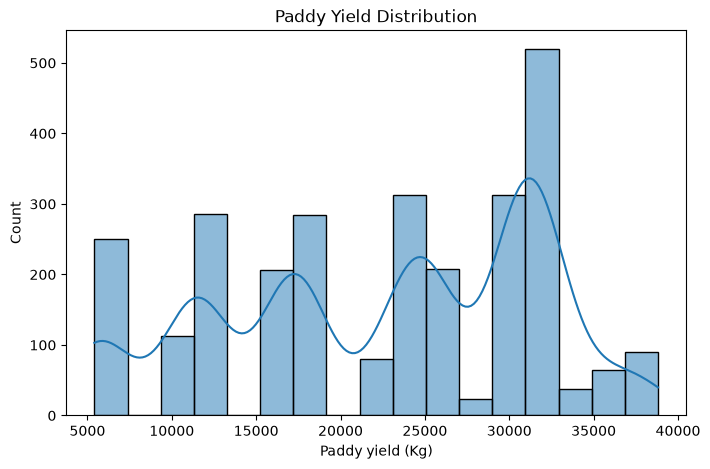

In [5]:
plt.figure(figsize=(8,5));
sns.histplot(df[TARGET],kde=True); 
plt.title('Paddy Yield Distribution'); 
plt.xlabel('Paddy yield (Kg)'); plt.show()

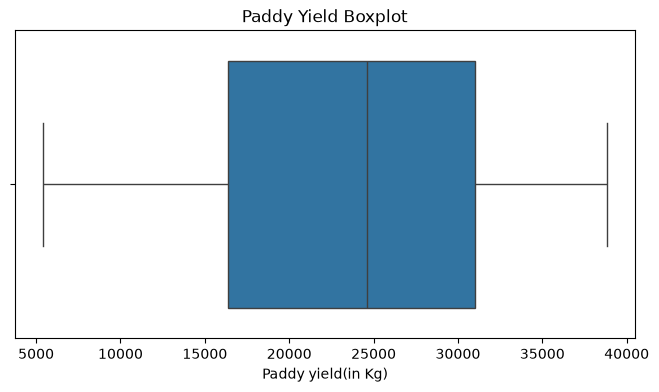

In [6]:
plt.figure(figsize=(8,4)); 
sns.boxplot(x=df[TARGET]); 
plt.title('Paddy Yield Boxplot');
plt.show()

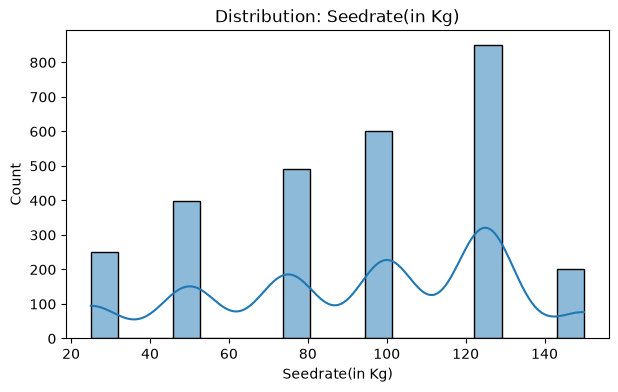

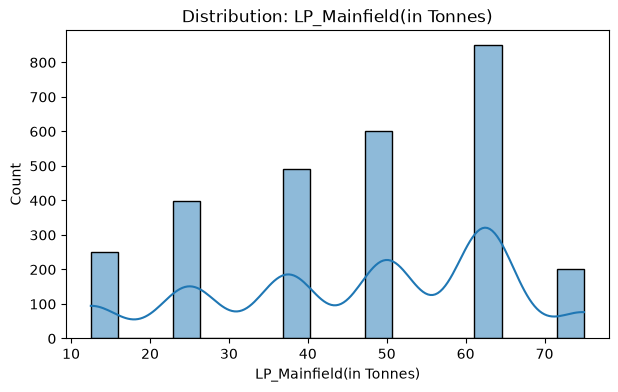

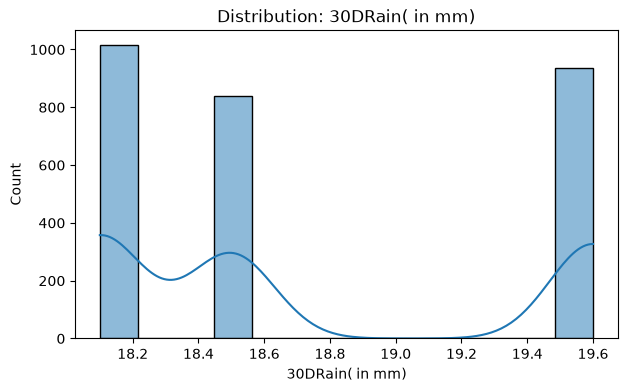

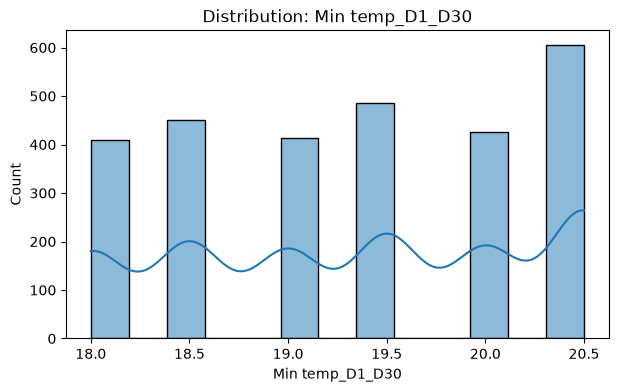

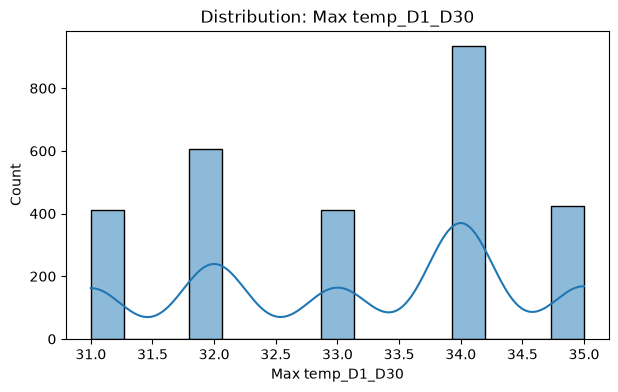

In [7]:
for c in ['Hectares ','Seedrate(in Kg)',
          'LP_Mainfield(in Tonnes)',
          '30DRain( in mm)',
          'Min temp_D1_D30',
          'Max temp_D1_D30']:
    if c in df.columns:
        plt.figure(figsize=(7,4)); 
        sns.histplot(df[c],kde=True); 
        plt.title(f'Distribution: {c}'); 
        plt.show()

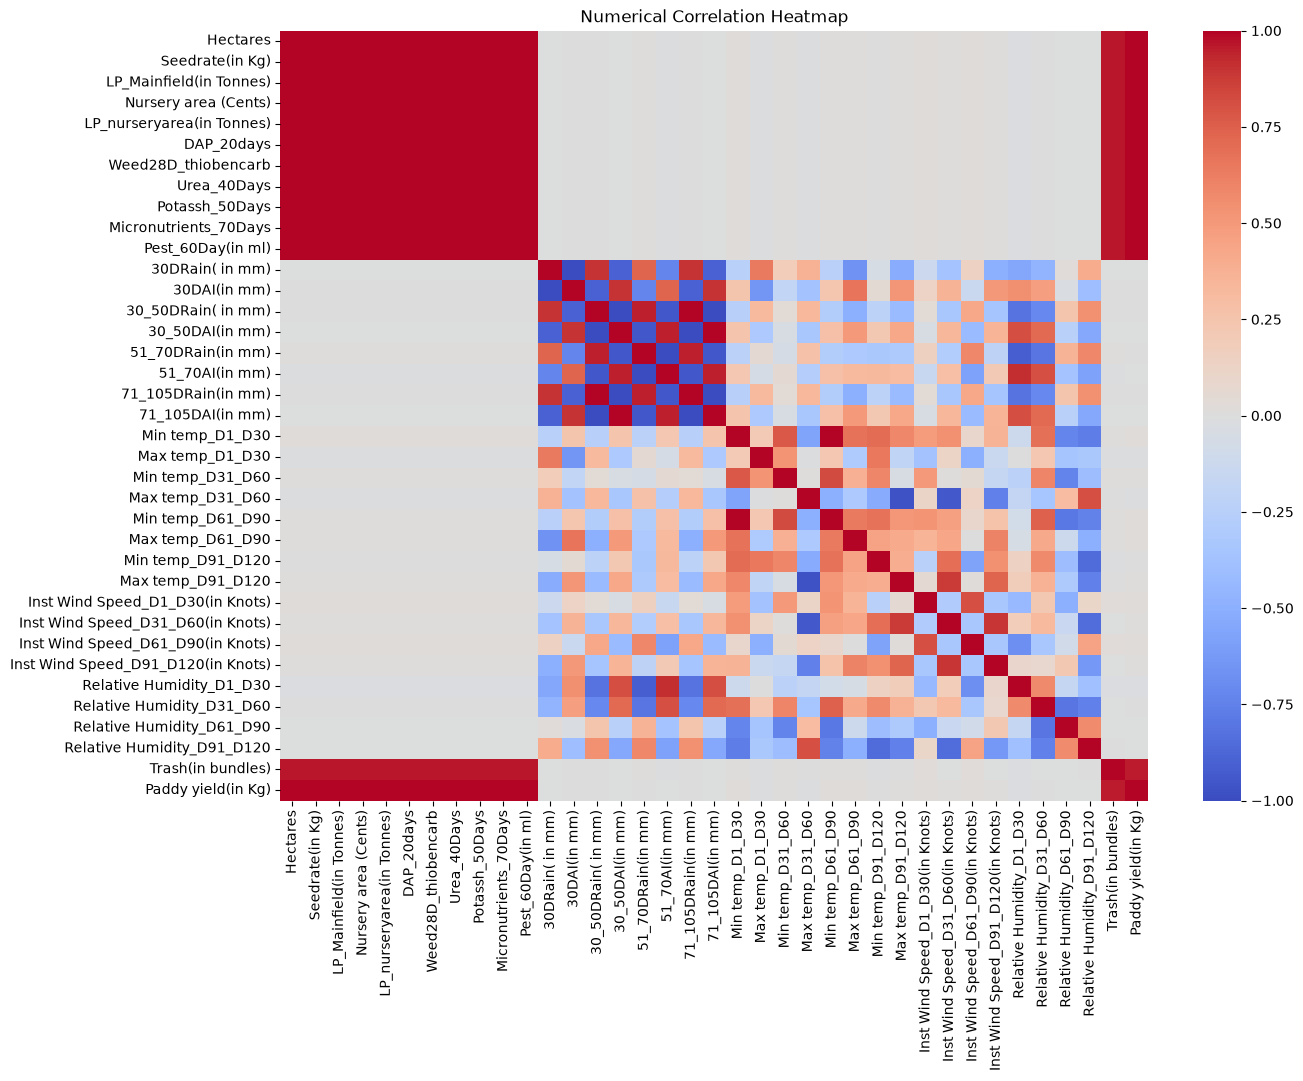

In [8]:
plt.figure(figsize=(14,10)); 
corr=df.select_dtypes(include=np.number).corr(); 
sns.heatmap(corr,cmap='coolwarm',center=0); 
plt.title('Numerical Correlation Heatmap'); 
plt.show()

In [9]:
top_corr=corr[TARGET].drop(TARGET).abs().sort_values(ascending=False).head(15)
display(top_corr.to_frame('Absolute Correlation with Target'))

,Absolute Correlation with Target
Urea_40Days,0.994649
Hectares,0.994649
LP_nurseryarea(in Tonnes),0.994649
Weed28D_thiobencarb,0.994649
Potassh_50Days,0.994649
DAP_20days,0.994649
Nursery area (Cents),0.994649
Micronutrients_70Days,0.994649
LP_Mainfield(in Tonnes),0.994649
Seedrate(in Kg),0.994649


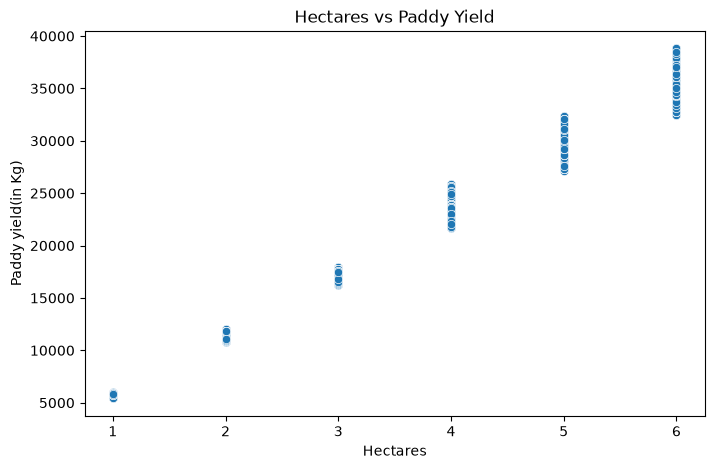

In [ ]:
plt.figure(figsize=(8,5));
sns.scatterplot(data=df,x='Hectares',y=TARGET);
plt.title('Hectares vs Paddy Yield');
plt.show()

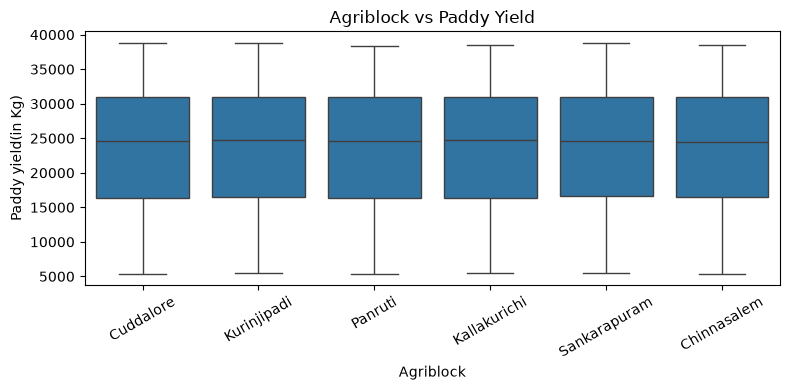

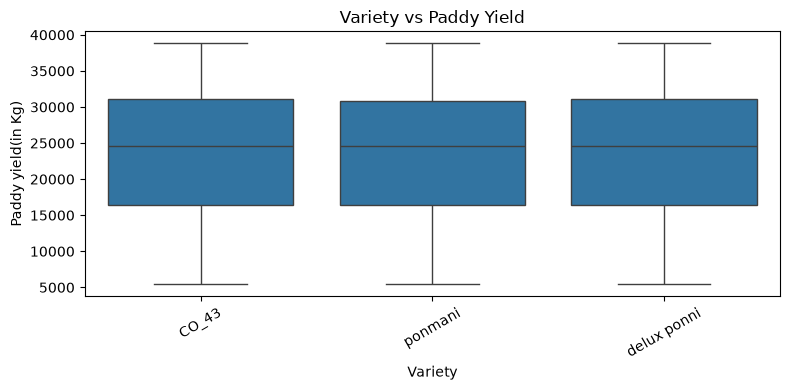

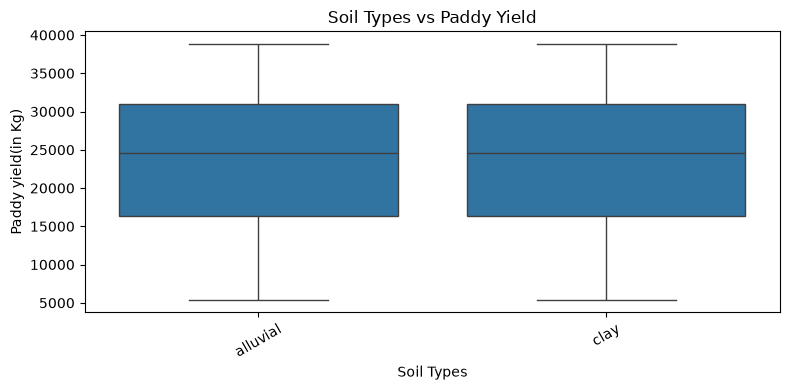

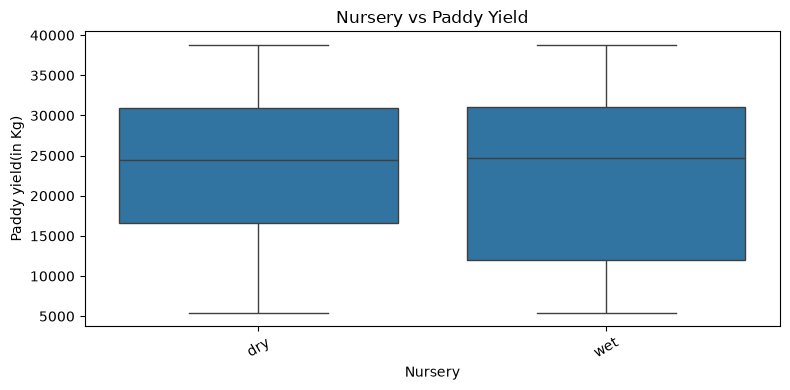

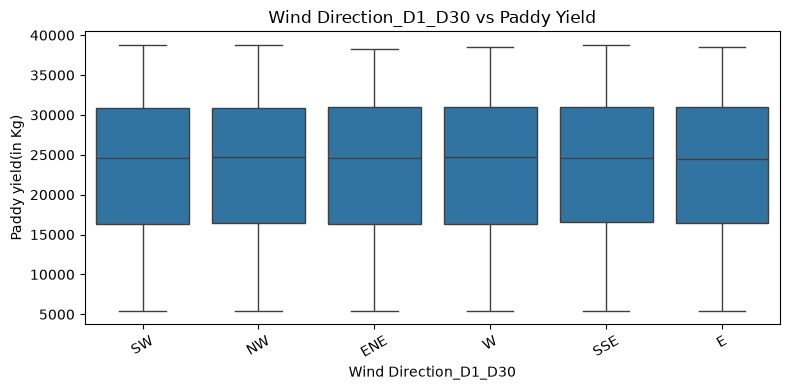

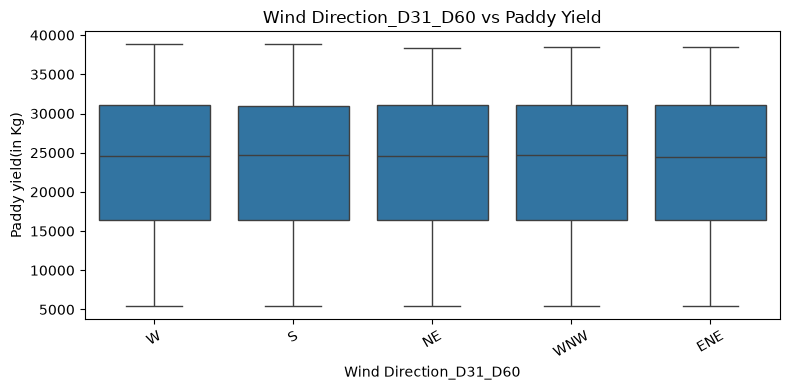

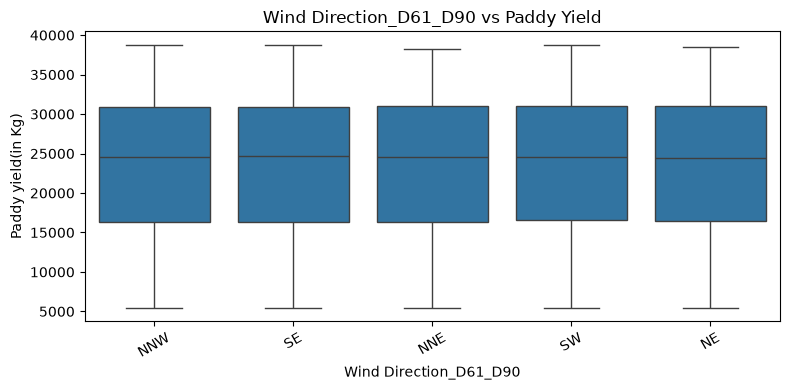

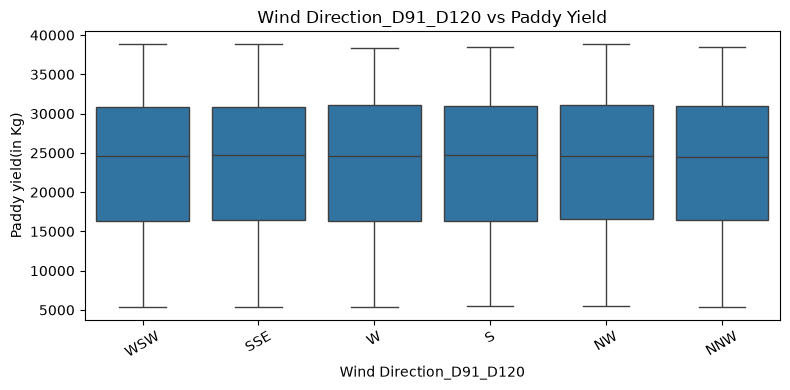

In [12]:
for c in cat_cols:
    plt.figure(figsize=(8,4)); 
    sns.boxplot(data=df,x=c,y=TARGET); 
    plt.xticks(rotation=30); 
    plt.title(f'{c} vs Paddy Yield'); 
    plt.tight_layout(); plt.show()